### Importación de Librerías y Configuración de Dispositivo
Este bloque prepara el entorno de entrenamiento y asegura reproducibilidad.
Incluye detección de hardware y ajuste de semillas para resultados consistentes.


In [2]:
import sys
import os
from pathlib import Path
import numpy as np
import random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Permitir importar módulos desde src/
BASE_DIR = Path("..")
sys.path.append(str(BASE_DIR))

from src.model import Autoencoder

# Fijar semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# CuDNN: reproducibilidad
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Detección de hardware (GPU o CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ Entrenando en dispositivo: {device}")

⚡ Entrenando en dispositivo: cpu


### Carga de Datos Procesados y PyTorch DataLoader
Se carga el conjunto de entrenamiento de transacciones normales.
El DataLoader usa `drop_last=True` para evitar batchs incompletos con BatchNorm1d.


In [3]:
# Ruta de los datos procesados para Credit Card
PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed" / "creditcard"
if not (PROCESSED_DATA_PATH / "X_train_licit.npy").exists():
    PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed"

# Cargar dataset de entrenamiento LÍCITO (Credit Card)
X_train_licit = np.load(PROCESSED_DATA_PATH / "X_train_licit.npy")
print(f"Dimensiones de X_train_licit (Credit Card): {X_train_licit.shape}")

# Convertir a Tensors de PyTorch
X_train_tensor = torch.tensor(X_train_licit, dtype=torch.float32)

# Crear Dataset y DataLoader con drop_last=True para prevenir fallos en BatchNorm1d
BATCH_SIZE = 256
train_dataset = TensorDataset(X_train_tensor)
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    drop_last=True
)

Dimensiones de X_train_licit (Credit Card): (170589, 30)


### Instanciación del Modelo, Criterio y Optimizador
Se define la arquitectura del autoencoder y se configuran sus hiperparámetros.
La pérdida utilizada es `MSELoss`, adecuada para reconstrucción de entradas continuas.


In [4]:
# Parámetros para Credit Card
INPUT_DIM = X_train_licit.shape[1]  # Detección automática del número de columnas
BOTTLENECK_DIM = 14                 # Compresión en espacio latente
LEARNING_RATE = 1e-3
EPOCHS = 50

# Instanciar modelo
model = Autoencoder(input_dim=INPUT_DIM, bottleneck_dim=BOTTLENECK_DIM).to(device)

# Función de pérdida y optimizador
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.2)
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=32, out_features=14, bias=True)
    (9): LeakyReLU(negative_slope=0.2)
  )
  (decoder): Sequential(
    (0): Linear(in_features=14, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=32, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=Tru

### Bucle de Entrenamiento (Training Loop)
Este bloque realiza la optimización del autoencoder sobre el conjunto normal.
Se registra la pérdida por época para monitorizar convergencia.


In [5]:
train_losses = []

model.train()
for epoch in range(1, EPOCHS + 1):
    running_loss = 0.0
    for batch in train_loader:
        inputs = batch[0].to(device)
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        
        # Backward pass y optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{EPOCHS}] - Loss (MSE): {epoch_loss:.6f}")

Epoch [01/50] - Loss (MSE): 0.587219
Epoch [05/50] - Loss (MSE): 0.313577
Epoch [10/50] - Loss (MSE): 0.281149
Epoch [15/50] - Loss (MSE): 0.270742
Epoch [20/50] - Loss (MSE): 0.260408
Epoch [25/50] - Loss (MSE): 0.257460
Epoch [30/50] - Loss (MSE): 0.257312
Epoch [35/50] - Loss (MSE): 0.252940
Epoch [40/50] - Loss (MSE): 0.253846
Epoch [45/50] - Loss (MSE): 0.247520
Epoch [50/50] - Loss (MSE): 0.246998


### Visualización de la Curva de Pérdida

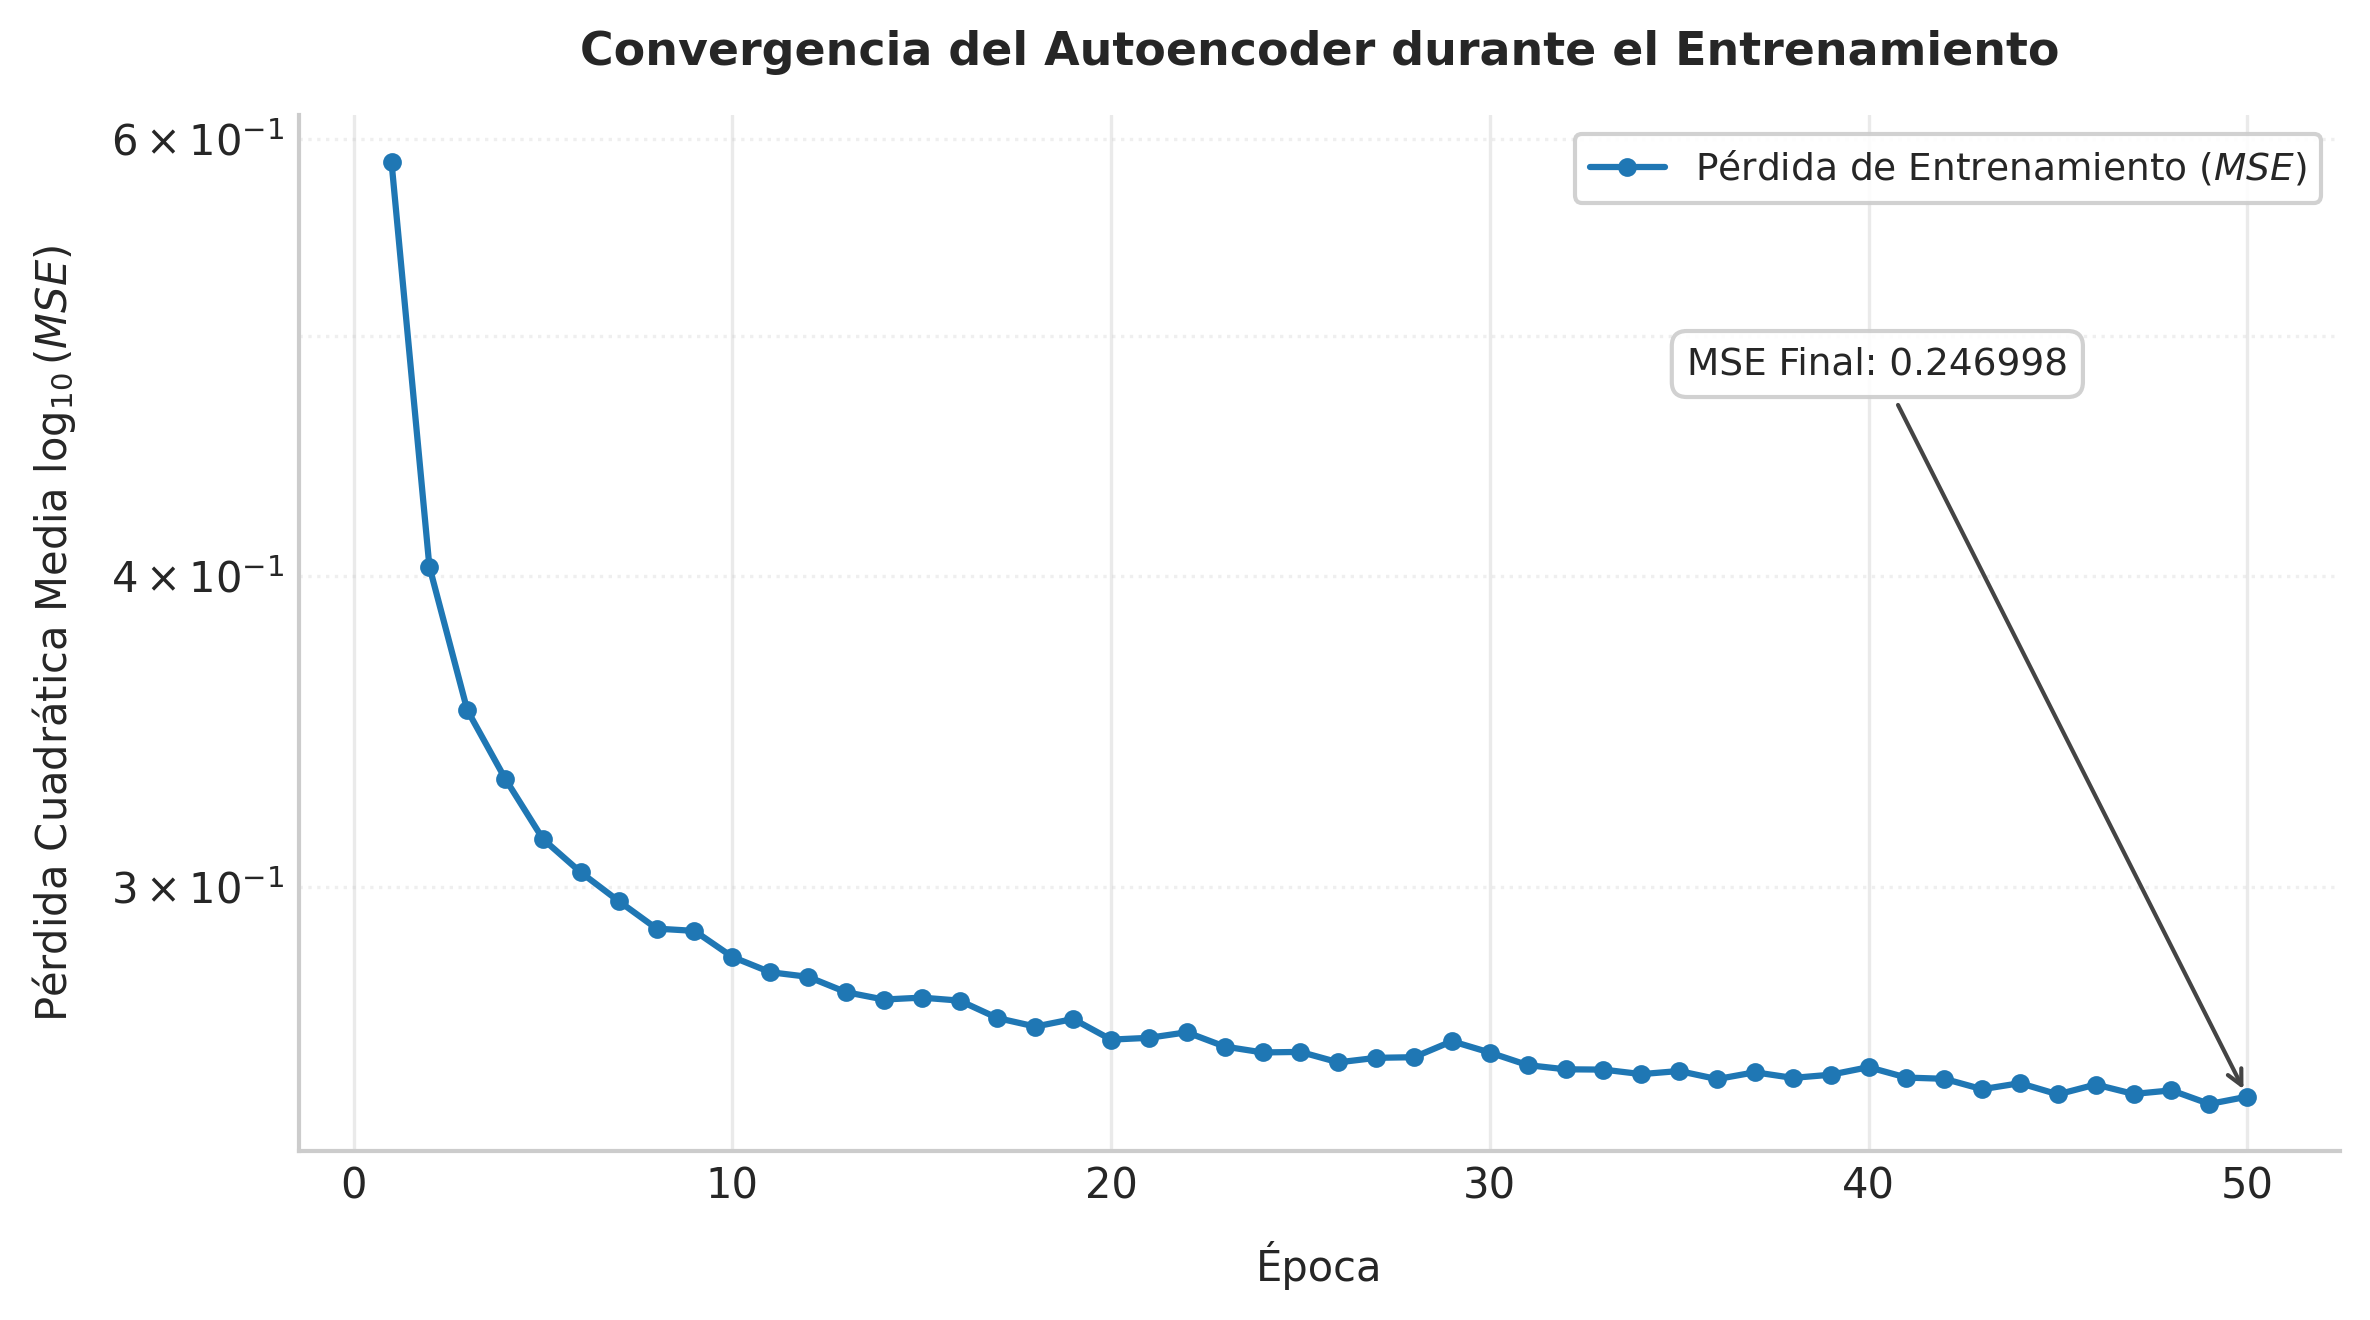

In [ ]:
import matplotlib.pyplot as plt

# Estilo global académico
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=300)

epocas = range(1, EPOCHS + 1)
color_loss = '#1f77b4'

# Graficar en escala semilogarítmica
ax.semilogy(epocas, train_losses, marker='o', markersize=3.5, linewidth=1.5, color=color_loss, label='Pérdida de Entrenamiento ($MSE$)')
# no se usó loglog por la poca cantidad de epocas
# Títulos y etiquetas claras
ax.set_title("Convergencia del Autoencoder durante el Entrenamiento", fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel("Época", fontsize=10, labelpad=8)
ax.set_ylabel("Pérdida Cuadrática Media $\\log_{10}(MSE)$", fontsize=10, labelpad=8)

# Rejilla principal y secundaria tenue para facilitar la lectura logarítmica
ax.grid(True, which='major', linestyle='-', alpha=0.4)
ax.grid(True, which='minor', linestyle=':', alpha=0.3)
ax.set_axisbelow(True)

# Limpieza de bordes innecesarios
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Anotación científica con el valor final
final_loss = train_losses[-1]
ax.annotate(
    f'MSE Final: {final_loss:.6f}', 
    xy=(EPOCHS, final_loss), 
    xytext=(0.68, 0.75), 
    textcoords='axes fraction',
    arrowprops=dict(arrowstyle='->', lw=1, color='#444444'),
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#cccccc', alpha=0.9)
)

ax.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

### Guardado del Modelo Entrenado

In [7]:
# Definir directorio para guardar los modelos
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Ruta del archivo de guardado
model_path = MODELS_DIR / "autoencoder_creditcard.pth"

# Estructurar el checkpoint con pesos y configuración relevante
checkpoint = {
    'epoch': EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'final_loss': train_losses[-1],
    'input_dim': INPUT_DIM,
    'bottleneck_dim': BOTTLENECK_DIM,
    'seed': SEED
}

# Guardar en disco
torch.save(checkpoint, model_path)
print(f"✅ Modelo y metadatos guardados exitosamente en: {model_path}")

✅ Modelo y metadatos guardados exitosamente en: ..\models\autoencoder_creditcard.pth
